# 0.0 Configurações Básicas


In [1]:
# No Google Colab esta célula montava o Drive (`google.colab` não existe no seu Mac).
# Raiz dos dados do projeto (pasta `data/` na raiz do repositório).
import os
BASE_DIR_LOCAL = os.path.join(os.getcwd(), "data")
print("Dados:", os.path.abspath(BASE_DIR_LOCAL))

Dados: /Users/noel/Faculdade/ML/Prova/data


# 1 - Rede neural convolucional pré-treinada



Em **aprendizado por transferência**, usamos um modelo existente para resolver problemas diferentes, mas relacionados. Basicamente, tentamos explorar o que foi aprendido em uma tarefa e melhorar a generalização em outra tarefa. Usamos os pesos pré-treinados do modelo ou a arquitetura do modelo para resolver nosso problema. Ideal para pequenos conjuntos de dados de imagem, pode ser usada para vários problemas de visão computacional.

**Uma rede pré-treinada é uma rede que foi previamente treinada em um grande e genérico dataset (como por exemplo, o [ImageNet](https://www.image-net.org/index.php)), e depois utilizar esse modelo para futuras classificações, aproveitando que a base é muito diversificada e com muitos dados, tendo imagens de objetos, animais etc.**

Conseguimos usar esse modelo treinado nesse conjunto de dados gigante para classificar outras imagens relacionadas a esta base.

**O aprendizado por transferência economiza tempo de treinamento, oferece melhor desempenho na maioria dos casos e reduz a necessidade de um conjunto de dados enorme. Não é um método generalizado, mas ajuda na resolução de problemas relacionados.**

**Existem duas formas de utilização de uma rede pré-treinada:**
- Extração de características e
- Classificação - Fine-tuning (algo como “afinação”).

Vamos ver cada uma dessas utilizações.


##1.1 Modelos disponíveis

[As aplicações do Keras](https://keras.io/api/applications/#inception3) fornecem  acesso a arquiteturas como **VGG16, VGG19, RESNET** e muito mais. Existem mais de 25 modelos disponíveis, com menção de suas principais precisões nas classificações ImageNet, parâmetros, profundidade e tamanho.

**Tanto o VGG16 quanto o VGG19 são arquiteturas de redes neurais convolucionais (CNNs) que possuem múltiplas camadas convolucionais e densamente conectadas, amplamente utilizadas para processamento de imagens e têm desempenhos excelentes em tarefas de classificação de imagens.**

VGG16 tem 16 camadas convolucionais, enquanto VGG19 tem 19 camadas convolucionais. Essa diferença na profundidade da rede tem implicações no desempenho e na complexidade computacional de cada modelo.

Em geral, VGG19 tem o potencial de atingir uma precisão ligeiramente maior em tarefas de classificação de imagens em comparação com o VGG16, devido ao seu maior número de camadas e capacidade de aprender representações mais complexas dos dados. No entanto, essa maior precisão vem com o custo de maior complexidade computacional e tempo de treinamento.

**No ImageNet, o modelo VGG16 atinge uma precisão de teste top 5, de cerca de 92,7%.**


**Então, Vamos usar o VGG16.**

#2 - Classificador de imagens de cães e gatos usando uma rede pré-treinada

Usaremos o modelo VGG16 pré-treinado na ImageNet para lidar com o problema de classificação de cães e gatos. O modelo VGG16 é integrado ao Keras, basta usá-lo diretamente.

A VGG16 pré-treinada já aprendeu filtros úteis como:
- bordas
- texturas
- formas padrões visuais mais complexos

##2.1 Extração de características

A extração de características consiste em usar representações aprendidas em uma rede anterior para extrair características importantes de novas amostras e então passar por um novo classificador que é treinado do zero por cima desse extrator de características.

In [2]:
#Essa classe representa a arquitetura da rede neural convolucional VGG16 (rede pré-treinada).
#a parte convolucional da VGG16 é utilizada para extrair características de imagens em novas tarefas.
from tensorflow.keras.applications import VGG16

conv_base = VGG16(weights='imagenet',       # O modelo é inicializado com os pesos pré-treinados no conjunto de dados ImageNet.
                  include_top=False,        # A camada de classificação (fully connected layers) no topo do modelo VGG16 original é excluída.
                                            # Queremos usar a parte convolucional do modelo (que extrai características) e
                                            # adicionar nossas próprias camadas de classificação personalizadas no topo.
                  input_shape=(150, 150, 3))# Define a forma das imagens de entrada que serão alimentadas ao modelo.
                                            # Neste caso, as imagens devem ter 150 pixels de largura, 150 pixels de altura e 3 canais de cor (RGB)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#exibe um resumo da arquitetura do modelo VGG16 que você carregou

conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Camadas:

- **Conv2D** significa Convolução 2D e representa uma camada convolucional bidimensional. A principal função de uma camada Conv2D é **extrair características da imagem, como bordas, cantos, texturas, etc**.
- **MaxPooling2D** representa uma camada de Max Pooling bidimensional, frequentemente utilizada em Redes Neurais Convolucionais (CNNs) para reduzir a dimensionalidade espacial dos mapas de características.  **Diminui a quantidade de dados a serem processados pelas camadas subsequentes, tornando o modelo mais eficiente e reduzindo o risco de overfitting**.

###2.1.1 Extração rápida de características, sem aprimoramento de dados

Em geral, esse método salva a saída de nossos dados após passar por **conv_base** e, em seguida, coloca essas saídas como entrada em um novo modelo.

Aqui, usamos a classe do Keras, **ImageDataGenerator**, que é usada para pré-processamento de imagens. Ela extrai imagens e rótulos em matrizes Numpy.

Em seguida, é chamado o método de previsão de conv_base para extrair recursos com o modelo pré-treinado.

Essa opção é a mais rápida e a que reque menos custo computacional. Contudo, não podemos aplicar o **data augmentation** (conjunto de técnicas que aumenta artificialmente o tamanho de um conjunto de dados de treinamento, criando cópias modificadas dos dados existentes ou gerando novos dados sintéticos a partir dos dados existentes).

O código abaixo, gasta (em torno) de 20 minutos para ser executado

In [4]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = BASE_DIR_LOCAL  # definido na primeira célula (rode essa célula antes)
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# módulo do framework Keras que realiza o pre-processamento das imagens:
# Decodificar o conteúdo em JPEG para RGB pixels
# Converter as imagens para tensores de ponto flutuante
#Reescalar os valores de pixels (0 a 255), para o intervalo de [0,1]
datagen = ImageDataGenerator(rescale=1./255) #divide cada valor de pixel por 255,
                                             #reescalando-os para o intervalo
                                             #desejado [0,1]
batch_size = 20 #indica que as imagens e seus rótulos serão processados em
                #lotes (batches) de 20 amostras por vez durante a extração de
                #características.

def extract_features(directory, sample_count):
    #cria um array com sample_count "fatias",
    #onde cada fatia é uma matriz 4x4 com 512 canais,
    #pronta para armazenar as características extraídas de uma imagem.
    features = np.zeros(shape=(sample_count, 4, 4, 512))  #Isso deve estar
                                                          #de acordo com a forma
                                                          #da saída da última
                                                          #camada de conv_base


    #cria um array zerado que irá armazenar os rótulos 0 ou 1 para cada imagem.
    labels = np.zeros(shape=(sample_count))

    #flow_from_directory é um método do keras,
    #usado para criar um gerador de dados (data generator)
    #lê imagens de um diretório e as
    #retorna em batches para treinamento de modelos de Deep Learning.
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary' #problema de classificação binária
    )

    i = 0
    for inputs_batch, labels_batch in generator: # Adicionar dados lote por lote
        features_batch = conv_base.predict(inputs_batch)#usando a conv_base para
                                                        #extrair as características
        features[i * batch_size : (i + 1) * batch_size] = features_batch
        labels[i * batch_size : (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:#O gerador irá gerar dados ilimitados,
             break                        #o intervalo deve ser
                                          #controlado por você

    return features, labels

train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)

Found 2000 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

O objetivo principal dos reshapes abaixo é transformar as features extraídas das imagens em um formato adequado para serem usadas como entrada em um classificador de rede neural totalmente conectado (fully connected).

Para enviar os dados para o modelo da rede neural, precisamos primeiro realizar o flatten dessas imagens para o tamanho de (samples, 8192 = 4 * 4 * 512). Isso significa que vamos multiplicar os pixels das imagens por 4*4, como mostrado abaixo.



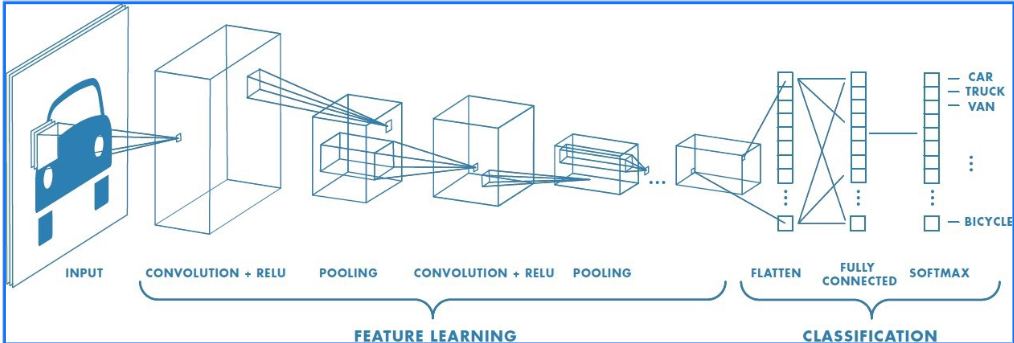

In [5]:
train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

As features de um conjunto de imagens foram extraídas utilizando a base convolucional da VGG16 (conv_base). Essas features serão utilizadas para treinar um classificador personalizado ou para outras tarefas de visão computacional.

Tendo isso, podemos ‘fitar’ o modelo. Então é fazer o classificador de conexão densa, ou usar a regularização de dropout:

In [7]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

model = models.Sequential()

#dimensão do tensor de entrada (vetor achatado) - Primeira camada densa
# número razoável de neurônios (+ utilizado) para classificar caes e gatos

model.add(layers.Dense(256, activation='relu', input_dim=4 * 4 * 512))

# Taxa de Dropout, que representa a probabilidade de um neurônio ser
#"desligado" (ignorado) durante o treinamento.
# Neste caso, 50% dos neurônios serão desligados aleatoriamente
# em cada época de treinamento.

model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid')) #saída, sigmoid porque é binária (class.)

#Em muitos cenários de deep learning, incluindo tarefas de visão computacional,
#RMSprop tem se mostrado um otimizador eficiente e com bom desempenho
model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5), #taxa de aprendizado muito pequena é crucial e faz sentido,
                                                                #especialmente no contexto de transfer learning
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(train_features, train_labels,
                    validation_data=(validation_features, validation_labels),
                    batch_size=20, #o tamanho do "lote"
                                   #de dados usado em cada iteração do treinamento
                    epochs=30
                    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.6745 - loss: 0.5972 - val_acc: 0.8440 - val_loss: 0.4388
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8090 - loss: 0.4141 - val_acc: 0.8620 - val_loss: 0.3636
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8555 - loss: 0.3515 - val_acc: 0.8820 - val_loss: 0.3236
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8640 - loss: 0.3163 - val_acc: 0.8830 - val_loss: 0.3029
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8765 - loss: 0.2942 - val_acc: 0.8850 - val_loss: 0.2889
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8945 - loss: 0.2674 - val_acc: 0.8950 - val_loss: 0.2740
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9010 - loss: 0.2585 - val_acc: 0.8950 - val_loss: 0.2689
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9065 - loss: 0.2409 - val_acc: 0.8990 - val_loss: 0.2591
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - ac

Este modelo é típico para tarefas de classificação de imagens, onde as características extraídas por camadas convolucionais anteriores são alimentadas em um classificador totalmente conectado (camadas densas) para prever a classe da imagem.

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,195,332 (16.00 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,097,667 (8.00 MB)

O treinamento é realmente mais rápido pois estamos lidando com duas camadas densamente conectadas (e uma época leva menos que 1 segundo de execução mesmo se utilizando uma CPU).

Veja o resultado da acurácia do treinamento e validação

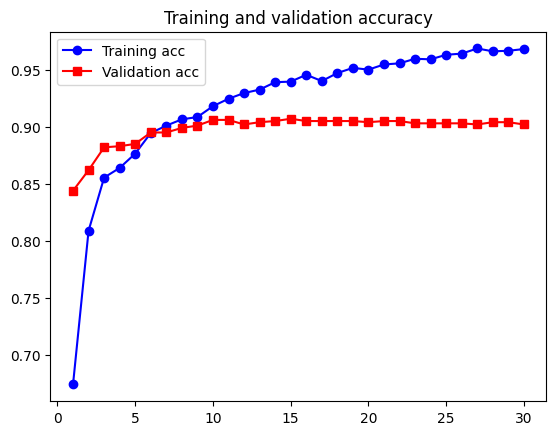

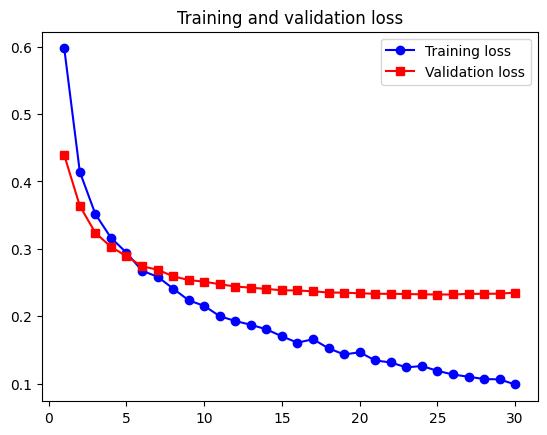

In [8]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo-', label='Training acc')
plt.plot(epochs, val_acc, 'rs-', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'rs-', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

 O gráfico da acurácia sugere um **leve overfitting**, mas não de forma crítica:
- Acurácia de Treinamento: A curva de acurácia de treinamento aumenta constantemente e se estabiliza em um nível alto, indicando que o modelo está aprendendo bem os dados de treinamento.
- Acurácia de Validação: A curva de acurácia de validação também aumenta, mas se estabiliza em um nível ligeiramente inferior à acurácia de treinamento. Essa pequena diferença sugere que o modelo está generalizando bem para novos dados, mas poderia estar memorizando alguns detalhes específicos do conjunto de treinamento.


Analisando o gráfico de perda temos:
- Perda de treinamento: Diminui consistentemente ao longo das épocas, indicando que o modelo está aprendendo com os dados de treinamento.
- Perda de validação: Também diminui e se estabiliza em um nível baixo, acompanhando a perda de treinamento.

A perda de treinamento e validação estão convergindo para valores baixos, indicando que o modelo está aprendendo as características relevantes dos dados.

A diferença entre as curvas de treinamento e validação, embora existindo nos dois gráficos, não é muito grande. Isso indica que o overfitting, se presente, não é severo.

 Isso pode ser combatido utilizando o **Data Augmentation** (aqui no caso, aumentar o número de instâncias). Sempre bom lembrar que **quando temos um conjunto de dados pequeno é muito provável que o modelo ‘overfite’**, por isso se faz necessário a utilização de técnicas que combatam esse problema.

A acurácia da base test

In [9]:
import tensorflow as tf


# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_features, test_labels)

# Print the test accuracy
print('Test accuracy:', test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.8880 - loss: 0.2524
Test accuracy: 0.8880000114440918


###2.1.2 Extração de características utilizando o Data Augmentation

Vamos fazer essa técnica que utiliza o Data augmentation para evitar o ‘overfite’, generalizando as imagens do conjunto de dados. **Esse modelo será mais lento no treinamento e consequentemente vai requerer maior hardware. Sendo impossível de ser executado em uma CPU, nesse caso teremos que recorrer a uma GPU**.

**Data Augmentation** é um conjunto de técnicas que aumentam artificialmente o tamanho de um conjunto de dados de treinamento. Isso pode ser feito criando cópias modificadas dos dados existentes ou gerando novos dados sintéticos a partir dos dados existentes.

O objetivo do Data Augmentation é aumentar a diversidade dos dados de treinamento, para que o modelo possa aprender a generalizar melhor para novos dados.

No código abaixo, o Data Augmentation é usado para gerar variações das imagens de cães e gatos, como **rotações, translações e flips horizontais**. Isso ajuda a evitar o overfitting, que é quando o modelo aprende os dados de treinamento muito bem, mas não generaliza bem para novos dados.

A ideia aqui é estender o conv_base que é o nosso VGG16 adicionando camadas densas. Como mostrado abaixo.

Vamos também **congelar** a conv_base antes de partir pro treinamento.

**Congelar (Freezing)** uma camada, ou conjunto de camadas, é o mesmo que evitar que seus pesos sejam atualizados durante o treinamento. Se a gente não fizer isso as representações que foram aprendidas anteriormente pela base convolucional será modificadas ao longo do treinamento. Isso daria uma bagunça nos nossos resultados.

Para realizar o freezing basta colocar o atributo **trainable** como False.

In [10]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

#código igual a anterior
conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))

#Novidade: congela a conv_base
conv_base.trainable = False


# Define a entrada do modelo explicitamente
inputs = tf.keras.layers.Input(shape=(150, 150, 3)) #imagens que serão processadas

# Conecta a conv_base na entrada, do modelo construído
x = conv_base(inputs)   # imagens de entrada são processadas pela base convolucional (VGG16),
                        # gerando um tensor de features como saída.
x = layers.Flatten()(x) # transforma o tensor 4D em um vetor unidimensional
x = layers.Dense(256, activation='relu')(x) # camada definida por nós, recebe o vetor achatado, adicionada a conv_base
outputs = layers.Dense(1, activation='sigmoid')(x)

# Cria o modelo com as entradas e saídas definidas
model1 = tf.keras.Model(inputs=inputs, outputs=outputs)

model1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Dê uma olhada no modelo:

Como podemos ver quando carregamos o sumário do conv_base (que é o mesmo do VGG16), esse tinha 14.714.688 parâmetros (**Trainable params**), que é algo muito grande. Agora temos um modelo que tem
2.097.665 (**Trainable params**), devido ao congelamento.

Agora vamos aplicar o Data augmentation nos dados e treinar o nosso modelo.

In [11]:
import os
base_dir = BASE_DIR_LOCAL
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

Duração do Processamento: 12 minutos

In [12]:
# Treine o modelo de ponta a ponta com uma base de convolução congelada

import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

tf.keras.utils.set_random_seed(42)


#Data augmentation, ocorre nos dados de treinamento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

validation_datagen = ImageDataGenerator(rescale=1./255)    # Observe que a validação não é aprimorado (não tem data augmentation)

test_datagen = ImageDataGenerator(rescale=1./255)    # Observe que o teste não é aprimorado (não tem data augmentation)

#O método flow_from_directory do ImageDataGenerator
#lê as imagens dos subdiretórios dentro do train_dir.
#Como a estrutura de diretórios é organizada por classes
#(por exemplo, subdiretórios 'cats' e 'dogs'),
#o flow_from_directory infere automaticamente os rótulos de cada imagem
#com base no nome do subdiretório em que ela se encontra.
train_generator = train_datagen.flow_from_directory(
    #diretorio target
    train_dir,
    #imagens serão redimensionadas para 150x150
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

#verificando os valores
for data_batch, labels_batch in validation_generator:
       print('data batch shape:', data_batch.shape)
       print('labels batch shape:', labels_batch.shape)
       print('data batch type:', data_batch.dtype)
       print('labels batch type:', labels_batch.dtype)
       break

model1.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=2e-5),
              metrics=['acc'])



#ao passar o train_generator para o model1.fit,
#o Keras sabe que o gerador é responsável por fornecer
#os dados de entrada (imagens) e os rótulos (classes)
#para cada passo de treinamento, e não é necessário passá-los separadamente.
history = model1.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    #validation_steps é necessário ser definido no método fit quando se usa um gerador para
    #validação e indica o número total de lotes a serem extraídos do gerador
    #de validação para avaliar a perda e as métricas no conjunto de validação
    #ao final de cada época de treinamento.


    #O cálculo correto para validation_steps é o número total de amostras de validação
    #dividido pelo batch_size do gerador de validação.
    #No nosso caso, temos 1000 imagens de validação e um batch_size de 20,
    #então 1000 / 20 = 50.
    validation_steps=50)



Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)
data batch type: float32
labels batch type: float32
Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 220ms/step - acc: 0.6895 - loss: 0.5886 - val_acc: 0.8060 - val_loss: 0.4528
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - acc: 0.7875 - loss: 0.4689 - val_acc: 0.8580 - val_loss: 0.3692
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - acc: 0.8060 - loss: 0.4287 - val_acc: 0.8720 - val_loss: 0.3289
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - acc: 0.8110 - loss: 0.4128 - val_acc: 0.8810 - val_loss: 0.3078
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - acc: 0.8245 - loss: 0.3858 - val_acc: 0.8850 - val_loss: 0.2924
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - acc: 0.8380 - loss: 0.3665 - val_acc: 0.8880 - val_loss: 0.2846
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━

Veja o resultado:

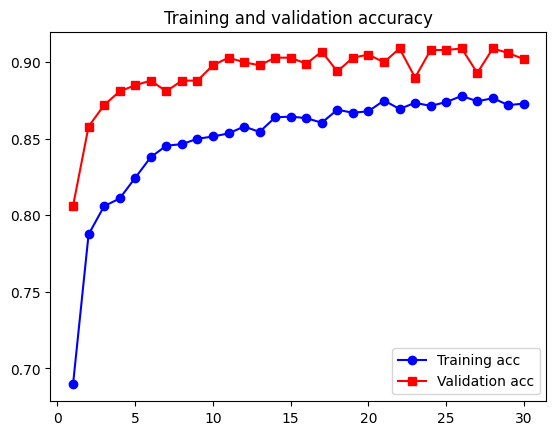

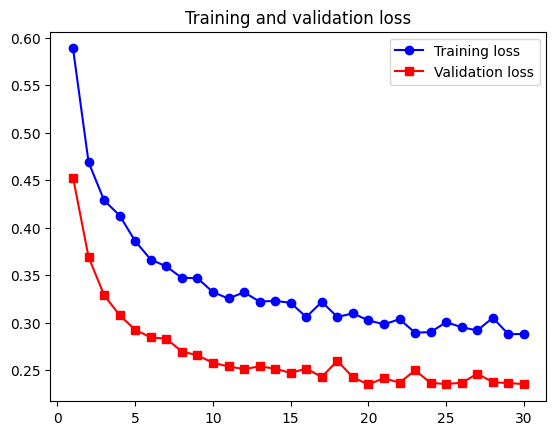

In [13]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo-', label='Training acc')
plt.plot(epochs, val_acc, 'rs-', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'rs-', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [14]:
#Quando você passa um gerador (como test_generator)
#para o método evaluate, o Keras precisa saber quantos lotes (batches) de dados
# extrair do gerador para calcular as métricas de avaliação (como perda e acurácia) em todo o conjunto de dados de teste.

#O cálculo correto para steps em model.evaluate() ao usar um gerador é
# o número total de amostras no conjunto de teste dividido pelo
# batch_size do gerador de teste.
# No nosso caso, temos 1000 imagens de teste e o batch_size é 20, então 1000 / 20 = 50.
#Portanto, steps=50 garante que 50 lotes de 20 imagens cada (totalizando 1000 imagens) sejam usados para a avaliação.
test_loss, test_acc = model1.evaluate(test_generator, steps=50)
print('test acc:', test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - acc: 0.8970 - loss: 0.2466
test acc: 0.8970000147819519


Antes: **acc = Test accuracy: 0.8880**

Vendo os gráficos acima, o problema de overfitting foi resolvido.

##2.2 Modelo de ajuste fino

O ajuste fino é para complementar a extração de recursos e otimizar ainda mais o modelo.

**O que o ajuste fino faz é descongelar as camadas no topo (perto da parte de trás) da base convolucional e treinar as camadas descongeladas e a parte recém-adicionada (classificador totalmente conectado) juntas**.

Este método ajusta ligeiramente as representações abstratas de alto nível no modelo de pré-treinamento (ou seja, aquelas próximas ao nível superior) para torná-las mais adequadas para o problema em questão.

Observe que o classificador final totalmente conectado deve ser treinado antes de ir para o bloco Conv no topo da base de convolução de ajuste fino, caso contrário, os resultados do pré-treinamento serão completamente destruídos.

As etapas para utilização dessa técnica são:

- Adicionar as camadas necessárias no topo da base da rede pré treinada.
- Congelar a base da rede
- Treinar a parte que foi adicionada
- Descongelar algumas camadas da rede base (VGG16)
- Treinar todo o conjunto de camadas.

Na extração de características utilizando Data Augmentation, podemos dizer que  **os 3 primeiros passos já foram realizados**. Então passamos direto para o passo 4 que é descongelar a convbase e congelar camadas individuais dessa base.

Primeiro, vamos ver nossa base de convolução VGG16:

In [15]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

Vamos descongelar **block5_conv1**, **block5_conv2** e **block5_conv3** para completar o ajuste fino.

**Elas são mais específicas do conjunto de treinamento original (ImageNet) - características de alto nível**. Para que o modelo se adapte melhor à sua tarefa de classificação de cães e gatos, você precisa permitir que essas últimas camadas convolucionais **ajustem seus pesos** para aprender características de alto nível que sejam mais discriminativas para cães e gatos.

Tempo de processamento com GPU T4:10 minutos

In [16]:
tf.keras.utils.set_random_seed(42)

# Descongela toda a conv_base
conv_base.trainable = True

#Congela conv_base até block4_pool
#Descongela conv_base: block5_conv1, block5_conv2 e block5_conv3
set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

# Ajustar o modelo

model1.compile(loss='binary_crossentropy',
              # A taxa de aprendizagem (lr) usada aqui é muito pequena,
              #espera-se que a representação ajustada de três níveis não mude muito
              optimizer=optimizers.RMSprop(learning_rate=1e-5),
              metrics=['acc'])

history = model1.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 219ms/step - acc: 0.8705 - loss: 0.2916 - val_acc: 0.8960 - val_loss: 0.2354
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 213ms/step - acc: 0.8815 - loss: 0.2672 - val_acc: 0.9020 - val_loss: 0.2404
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - acc: 0.9045 - loss: 0.2471 - val_acc: 0.9140 - val_loss: 0.2165
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - acc: 0.9020 - loss: 0.2257 - val_acc: 0.9150 - val_loss: 0.1855
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - acc: 0.9160 - loss: 0.2006 - val_acc: 0.9170 - val_loss: 0.1904
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - acc: 0.9195 - loss: 0.1884 - val_acc: 0.9240 - val_loss: 0.1779
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - acc: 0.9220 - loss: 0.1824 - val_acc: 0.9260 - val_loss: 0.1838
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - acc: 0.9280 - loss: 0.1770 - val_acc: 0.9290 - val_loss: 0.1791
Epoch 9/30
100/100 ━━━━━━━━━━━━━

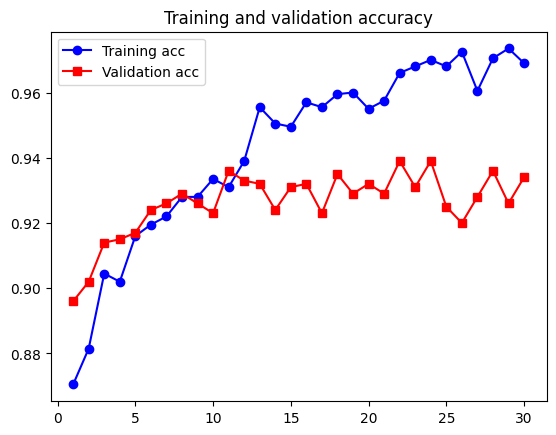

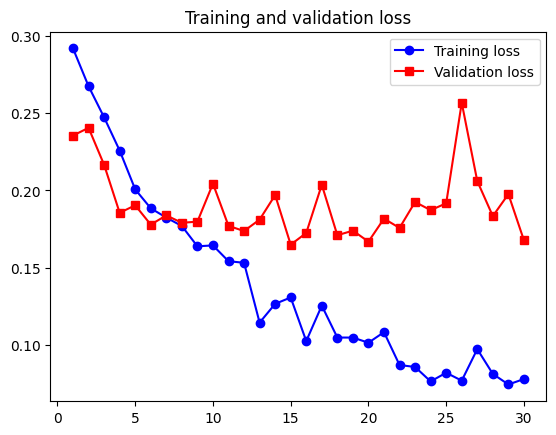

In [17]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo-', label='Training acc')
plt.plot(epochs, val_acc, 'rs-', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'rs-', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [18]:
test_loss, test_acc = model1.evaluate(test_generator, steps=50)
print('test acc:', test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - acc: 0.9380 - loss: 0.1821
test acc: 0.9380000233650208


Antes: **acc = 0.8970**

In [19]:
model1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,989,444 (99.14 MB)

 Trainable params: 9,177,089 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 9,177,091 (35.01 MB)

In [20]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Processamento demora em torno de 35 minutos (rodando com GPU T4)

Aumentamos as épocas, epochs=100, antes era 30

In [21]:
tf.keras.utils.set_random_seed(42)

# Descongela toda a conv_base
conv_base.trainable = True

#Congela conv_base até block4_pool
#Descongela conv_base: block5_conv1, block5_conv2 e block5_conv3
set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

# Ajustar o modelo

model1.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-5),    # A taxa de aprendizagem (lr) usada aqui é muito pequena, espera-se que a representação ajustada de três níveis não mude muito
              metrics=['acc'])

history = model1.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50) #20

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 221ms/step - acc: 0.9820 - loss: 0.0594 - val_acc: 0.9370 - val_loss: 0.1710
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - acc: 0.9800 - loss: 0.0498 - val_acc: 0.9220 - val_loss: 0.2448
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - acc: 0.9775 - loss: 0.0602 - val_acc: 0.9410 - val_loss: 0.1673
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - acc: 0.9840 - loss: 0.0476 - val_acc: 0.9340 - val_loss: 0.1820
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - acc: 0.9870 - loss: 0.0350 - val_acc: 0.9400 - val_loss: 0.1750
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - acc: 0.9870 - loss: 0.0433 - val_acc: 0.9410 - val_loss: 0.1922
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - acc: 0.9815 - loss: 0.0426 - val_acc: 0.9330 - val_loss: 0.1908
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - acc: 0.9880 - loss: 0.0382 - val_acc: 0.9410 - val_loss: 0.1793
Epoch 9/100
100/100 ━━━━

Veja o resultado com 100 épocas

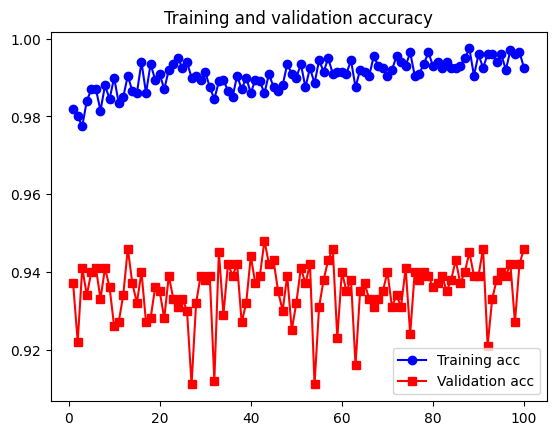

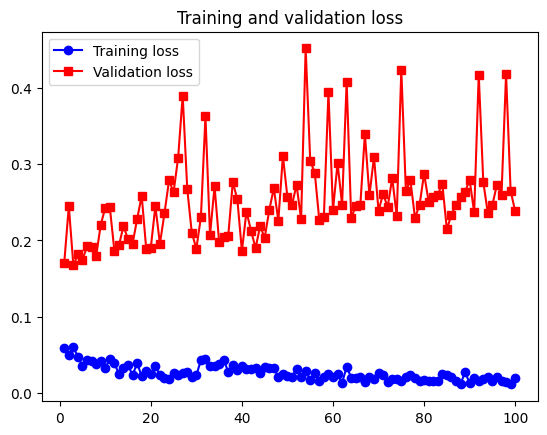

In [22]:
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo-', label='Training acc')
plt.plot(epochs, val_acc, 'rs-', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'rs-', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [23]:

test_loss, test_acc = model1.evaluate(test_generator, steps=50)
print('test acc:', test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - acc: 0.9420 - loss: 0.3241
test acc: 0.9419999718666077


Antes **acc= 0.9380**

O aumento do número de épocas de 30 para 100 resultou em um ganho marginal de acurácia (de 0,9380 para 0,9420). Essa melhoria de apenas **0,4%** não é expressiva quando comparada ao aumento significativo no custo computacional.

Além disso, incrementos tão pequenos podem estar associados a variações naturais do processo de treinamento, não representando necessariamente uma melhoria consistente na capacidade de generalização do modelo.

Dessa forma, é melhor manter manter um número menor de épocas, garantindo maior eficiência sem perda relevante de desempenho.

As redes neurais convolucionais são o melhor tipo de modelo para machine learning em visão computacional. Completamente possível construir uma rede do zero mesmo tendo poucos dados para trabalhar e ainda alcançamos resultados interessantes.

Num conjunto de dados pequenos o nosso maior desafio será o overfitting. O data augmentation é uma técnica poderosa para combater esse problema.